# Lab 13 Connected Component Analysis and Hierarchical Clustering

In [4]:
!pip install scikit-learn numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [5]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle, islice

I provide a function to plot clusters of points. I encourage you to change its parameters and explore what happens. 
[datasets](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.datasets) provides documentation if you want to explore with further datasets provided by scikit-learn. Here, we explore 4 toy datasets:

* **Circles:** 2 concentric circles. We would like to see datapoints in each circle assigned to the same cluster
* **Two moons:** 2 half moons placed with one end into the opening of the other. We would like to see datapoints in each moon assigned to the same cluster.
* **Separated Blobs of datapoints:** We would like to see datapoints in each blob asssigned to the same cluster.
* **Separated Blobs of datapoints with different variance:** We would like to see datapoints in each blob asssigned to the same cluster

TIPS:
* some of the generated datasets have different number of clusters, be sure to take that into account when fitting the data

In [6]:
n_samples = 1500
# Load datasets
circles_points, circles_labels = datasets.make_circles(n_samples=n_samples, factor=0.4, noise=.05)
two_moons_points, two_moons_labels = datasets.make_moons(n_samples=n_samples, noise=.05)
blobs_points, blobs_labels = datasets.make_blobs( # type: ignore
    n_samples=n_samples, 
    cluster_std=[.5, .5, .5],
    random_state=200
)
varied_points, varied_labels = datasets.make_blobs( # type: ignore
    n_samples=n_samples,
    cluster_std=[1.0, 1.3, 0.5],
    random_state=150
)


In [7]:

def plot_clusters(X, labels=None, title=''):
    palette = ['green', 'crimson', 'gold', 'steelblue', 'orange']
    if labels is None:
        labels = [0] * X.shape[0]
        colors = np.array(['red'] * X.shape[0])
    else:
        colors = np.array(list(islice(cycle(palette), int(max(labels) + 1))))
    plt.figure()
    plt.scatter(X[:,0], X[:,1], s=10, color = colors[labels])
    plt.title(title)
    plt.show()

def plot_clusters_subplots(datasets, labels_list=None, titles=None, n_cols=2, figsize=(10, 8)):
    palette = ['green', 'crimson', 'gold', 'steelblue', 'orange']
    n_plots = len(datasets)
    n_rows = int(np.ceil(n_plots / n_cols))

    if labels_list is None:
        labels_list = [None] * n_plots
    if titles is None:
        titles = [''] * n_plots

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.asarray(axes).reshape(-1)

    for ax, X, labels, title in zip(axes, datasets, labels_list, titles):
        X = np.asarray(X)

        if labels is None:
            labels = np.zeros(X.shape[0], dtype=int)
            colors = np.array(['red'])
        else:
            labels = np.asarray(labels)
            colors = np.array(list(islice(cycle(palette), int(np.max(labels) + 1))))

        ax.scatter(X[:, 0], X[:, 1], s=10, color=colors[labels])
        ax.set_title(title)

    for ax in axes[n_plots:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

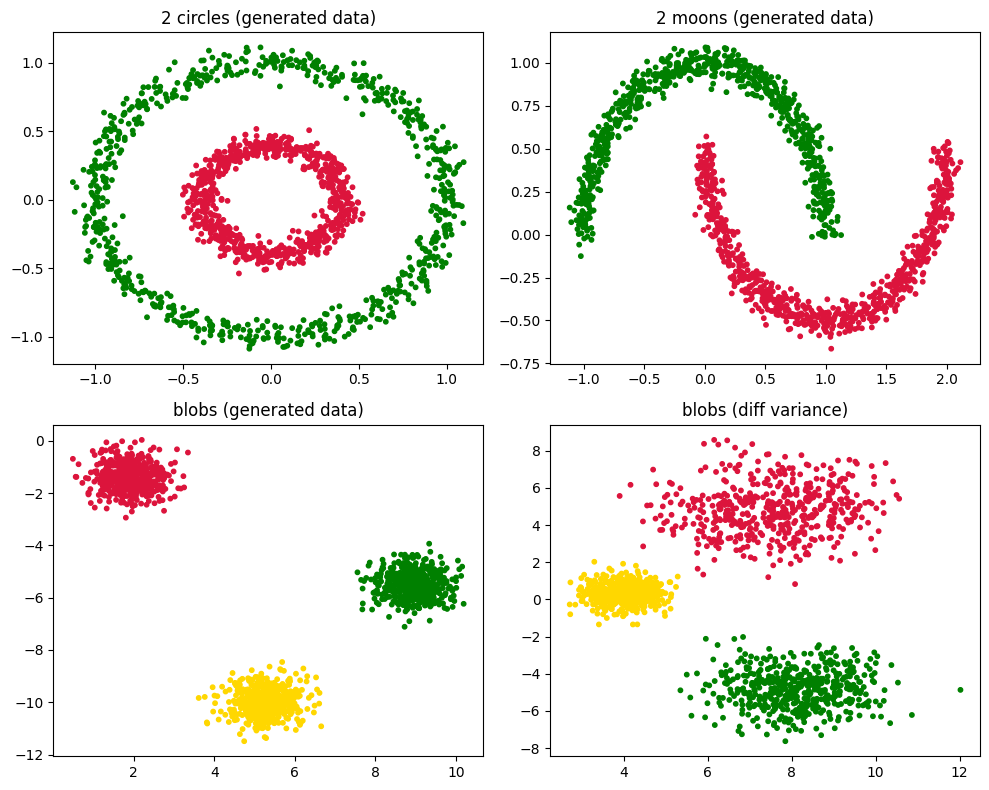

In [8]:
#visualise all the toy datasets
plot_clusters_subplots(
    datasets=[circles_points, two_moons_points, blobs_points, varied_points],
    labels_list=[circles_labels, two_moons_labels, blobs_labels, varied_labels],
    titles=[
        '2 circles (generated data)',
        '2 moons (generated data)',
        'blobs (generated data)',
        'blobs (diff variance)',
    ],
)

### Exercise 1: Connected Component Analysis

Implement Connected Component Analysis from scratch. Treat each datapoint as a node in a graph, compute all pairwise Euclidean distances, and build an adjacency matrix using a threshold `tau`. In this exercise, connect two points when their distance is smaller than `tau`.

The clusters are the connected components of this graph. Complete the function below so that it returns:

* `labels`: one integer cluster label per datapoint
* `distances`: the full pairwise distance matrix
* `adjacency`: the thresholded graph as a boolean matrix

After implementing the function, run the next cell and experiment with different values of `tau`.

In [34]:
def connected_component_analysis(X, tau):
    """
    Cluster datapoints using connected components in a threshold graph.

    Parameters
    ----------
    X : ndarray of shape (n_points, n_features)
        Dataset to cluster.
    tau : float
        Distance threshold used to decide whether two points are linked.

    Returns
    -------
    labels : ndarray of shape (n_points,)
        Component label for each datapoint.
    distances : ndarray of shape (n_points, n_points)
        Pairwise Euclidean distance matrix.
    adjacency : ndarray of shape (n_points, n_points)
        Boolean adjacency matrix for the threshold graph.
    """
    X = np.asarray(X)
    n_points = X.shape[0]

    # Step 1: compute all pairwise Euclidean distances.
    # Hint: NumPy broadcasting can create all pairwise differences at once.
    differences = X[:, None, :] - X[None, :, :]
    distances = np.sqrt(np.sum(differences ** 2, axis=-1))

    # Step 2: build the adjacency matrix using distance < tau.
    # Remember to remove self-links on the diagonal.
    adjacency = distances < tau
    np.fill_diagonal(adjacency, False)

    # Step 3: traverse the graph with DFS or BFS and assign component labels.
    labels = np.full(n_points, -1, dtype=int)
    current_label = 0

    # DFS
    for i in range(n_points):
        if labels[i] != -1:
            continue

        labels[i] = current_label
        stack = [i]
        while stack:
            node = stack.pop()
            
            empty_neighbors = np.where(adjacency[node] & (labels == -1))[0]
            for neighbor in empty_neighbors:
                labels[neighbor] = current_label
                stack.append(neighbor)
        
        current_label += 1

    return labels, distances, adjacency

2 circles: 2 clusters


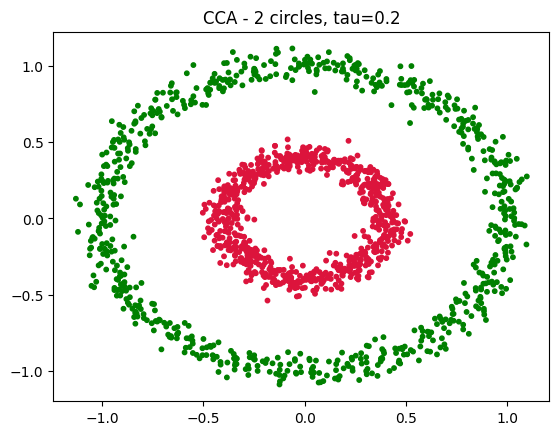

2 moons: 2 clusters


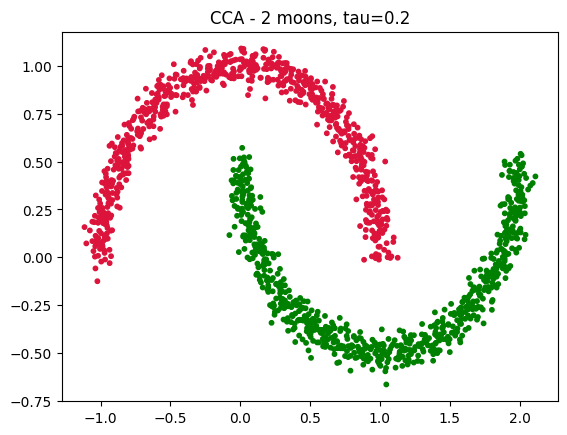

blobs: 75 clusters


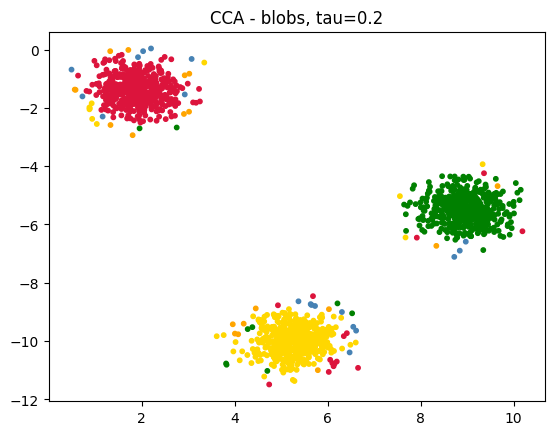

blobs (diff variance): 240 clusters


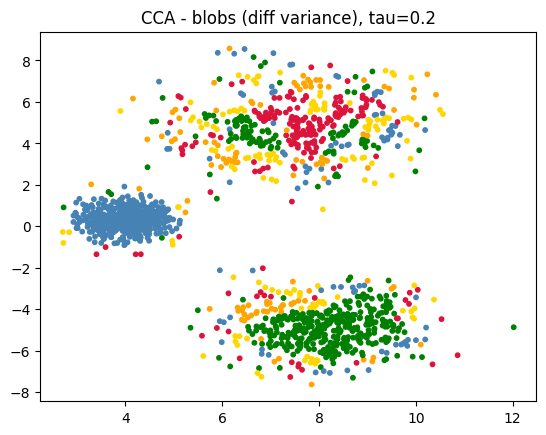

In [42]:
tau = 0.2

toy_datasets = [
    (circles_points, '2 circles'),
    (two_moons_points, '2 moons'),
    (blobs_points, 'blobs'),
    (varied_points, 'blobs (diff variance)'),
]

for points, name in toy_datasets:
    labels, distances, adjacency = connected_component_analysis(points, tau)
    unique_labels = np.unique(labels)

    print(f'{name}: {len(unique_labels)} clusters')
    plot_clusters(points, labels, title=f'CCA - {name}, tau={tau}')

## Hierarchical Clustering

### Exercise 2: Average-Linkage Hierarchical Clustering

Now implement agglomerative hierarchical clustering with average linkage (UPGMA), following the lecture PDF. Start with each datapoint as a cluster. At each step, merge the two closest clusters and update distances from the new cluster $Z = X \cup Y$ to another cluster $W$ using:

$$
d_{ZW} = \frac{N_X d_{XW} + N_Y d_{YW}}{N_X + N_Y}
$$

Your implementation should create a SciPy-compatible linkage matrix with rows of the form `[cluster_a, cluster_b, merge_distance, new_cluster_size]`. We will use SciPy only to draw the dendrogram, not to perform the clustering.

The demo uses a small reproducible subsample of each dataset so the dendrogram is readable. Use `k=2` for circles and moons, and `k=3` for the two blob datasets.

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler


def hierarchical_clustering_average_linkage(X):
    """
    Build a linkage matrix using handwritten average-linkage clustering.
    """
    X = np.asarray(X, dtype=float)
    n_points = X.shape[0]

    if n_points < 2:
        raise ValueError('Hierarchical clustering needs at least two points.')

    def pair_key(cluster_a, cluster_b):
        return tuple(sorted((cluster_a, cluster_b)))

    # Suggested steps:
    # 1. Create one active cluster per datapoint.
    active_clusters = set(range(n_points))
    
    # 2. Store each cluster size.
    cluster_sizes = {i: 1 for i in range(n_points)}
    
    # 3. Compute the initial pairwise distances between datapoints.
    differences = X[:, None, :] - X[None, :, :]
    distances = np.sqrt(np.sum(differences ** 2, axis=-1))
    
    dists = {}
    for i in range(n_points):
        for j in range(i + 1, n_points):
            dists[pair_key(i, j)] = distances[i, j]
    
    linkage_matrix = []
    next_cluster_id = n_points

    # 4. Repeatedly choose the closest pair of active clusters.
    while len(active_clusters) > 1: # 7. Stop when only one cluster remains.

        min_dist = float('inf')
        closest_pair = None

        for pair, dist in dists.items():
            if dist < min_dist:
                min_dist = dist
                closest_pair = pair

        left, right = closest_pair
        merge_distance = dists[closest_pair]

        size_left = cluster_sizes[left]
        size_right = cluster_sizes[right]
        new_size = size_left + size_right

        # 5. Append one linkage row: [left, right, merge_distance, new_size].
        linkage_matrix.append([left, right, merge_distance, new_size])

        cluster_sizes[next_cluster_id] = new_size
        active_clusters.remove(left)
        active_clusters.remove(right)

        # 6. Update distances to the newly created cluster using average linkage.
        for cluster in active_clusters:
            dist_left = dists[pair_key(left, cluster)]
            dist_right = dists[pair_key(right, cluster)]

            new_dist = (size_left * dist_left + size_right * dist_right) / new_size
            dists[pair_key(next_cluster_id, cluster)] = new_dist

        active_clusters.add(next_cluster_id)
        next_cluster_id += 1

    return np.array(linkage_matrix)


def labels_from_linkage(linkage_matrix, n_points, n_clusters):
    """
    Cut a linkage matrix to obtain exactly n_clusters labels.
    """
    # Suggested steps:
    # 1. Start with one active cluster per datapoint.
    # 2. Apply the first n_points - n_clusters merges.
    # 3. Assign one label to each remaining active cluster.

    # Your code here
    raise NotImplementedError('Complete labels_from_linkage')


def sample_dataset(X, sample_size=80, random_state=42):
    X = np.asarray(X)
    rng = np.random.default_rng(random_state)
    sample_size = min(sample_size, X.shape[0])
    sample_indices = rng.choice(X.shape[0], size=sample_size, replace=False)
    return X[sample_indices], sample_indices


def plot_hclust_before_after(X, linkage_matrix, labels, title):
    palette = ['green', 'crimson', 'gold', 'steelblue', 'orange']
    colors = np.array(list(islice(cycle(palette), int(np.max(labels) + 1))))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(X[:, 0], X[:, 1], s=18, color='red')
    axes[0].set_title(f'{title} - before')

    dendrogram(linkage_matrix, ax=axes[1], no_labels=True)
    axes[1].set_title(f'{title} - dendrogram')
    axes[1].set_xlabel('datapoints')
    axes[1].set_ylabel('distance')

    axes[2].scatter(X[:, 0], X[:, 1], s=18, color=colors[labels])
    axes[2].set_title(f'{title} - after')

    plt.tight_layout()
    plt.show()

Run the next cell to test your implementation on a tiny dataset and visualise the results.

In [45]:
# Run this cell after completing the hierarchical clustering functions.
# It will test your implementation on a tiny dataset and visualise the results.
tiny_points = np.array([[0.0], [1.0], [5.0], [6.0]])
tiny_linkage = hierarchical_clustering_average_linkage(tiny_points)
tiny_labels = labels_from_linkage(tiny_linkage, n_points=tiny_points.shape[0], n_clusters=2)

assert tiny_linkage.shape == (tiny_points.shape[0] - 1, 4)
assert tiny_linkage[-1, 3] == tiny_points.shape[0]
assert len(np.unique(tiny_labels)) == 2
assert np.all(np.diff(tiny_linkage[:, 2]) >= 0)

print('Average-linkage hierarchical clustering checks passed.')

NotImplementedError: Complete hierarchical_clustering_average_linkage

Test your implementation using the same datasets as in Exercise 1. Feel free to experiment with different number of sample size

In [ ]:
hclust_sample_size = 80
hclust_random_state = 42

hclust_datasets = [
    (circles_points, '2 circles', 2),
    (two_moons_points, '2 moons', 2),
    (blobs_points, 'blobs', 3),
    (varied_points, 'blobs (diff variance)', 3),
]

for points, name, n_clusters in hclust_datasets:
    sampled_points, _ = sample_dataset(
        points,
        sample_size=hclust_sample_size,
        random_state=hclust_random_state,
    )
    X = StandardScaler().fit_transform(sampled_points)

    linkage_matrix = hierarchical_clustering_average_linkage(X)
    labels = labels_from_linkage(linkage_matrix, X.shape[0], n_clusters=n_clusters)

    print(f'{name}: {len(np.unique(labels))} clusters')
    plot_hclust_before_after(X, linkage_matrix, labels, f'Average linkage - {name}')